<a href="https://colab.research.google.com/github/jdaltongit/CSCI580_Jesse_Dalton/blob/main/Assignment_4/TSP_SA_and_GA_Assignment_Skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TSP Optimization with Simulated Annealing and Genetic Algorithms — Assignment Notebook

Works in **Jupyter** and **Google Colab**.

## Overview
You will solve the same TSP instance using **two heuristic optimization methods**:

1. **Simulated Annealing (SA)** with a 2-opt neighborhood  
2. **Genetic Algorithm (GA)** on **permutation tours** (a standard evolutionary approach for TSP)

The notebook provides:
- A reproducible TSP instance generator
- Tour utilities (length, validity)
- A 2-opt neighborhood operator
- Visualization helpers (tour plot + history plot)
- Baseline heuristic: nearest neighbor

## Tasks
### Task A — Simulated Annealing (SA)
Implement `simulated_annealing_tsp(...)`.

### Task B — Genetic Algorithm (GA)
Implement `genetic_algorithm_tsp(...)` plus helper functions:
- Tournament selection
- Order crossover (OX)
- Swap mutation

## Deliverables
- Completed notebook (or exported `.py`) (find all TODOs and implement them)
- Short write-up (more detail in Part 6):
  - SA parameters + best length
  - GA parameters + best length
  - Brief comparison: which worked better and why

---


In [63]:
# If running in a fresh environment, uncomment as needed:
# !pip -q install matplotlib

import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt


## Part 1 — TSP utilities (provided)

In [64]:
Point = Tuple[float, float]
Tour = List[int]

def make_cities(n: int = 40, seed: int = 7) -> List[Point]:
    # Reproducible 2D city coordinates in [0, 1]x[0, 1].
    rng = random.Random(seed)
    return [(rng.random(), rng.random()) for _ in range(n)]

def dist(a: Point, b: Point) -> float:
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.hypot(dx, dy)

def tour_length(cities: List[Point], tour: Tour) -> float:
    # Total length of a closed tour.
    n = len(tour)
    total = 0.0
    for i in range(n):
        total += dist(cities[tour[i]], cities[tour[(i + 1) % n]])
    return total

def is_valid_tour(tour: Tour, n: int) -> bool:
    return len(tour) == n and set(tour) == set(range(n))

def random_tour(n: int, rng: random.Random) -> Tour:
    t = list(range(n))
    rng.shuffle(t)
    return t

def nearest_neighbor_tour(cities: List[Point], start: int = 0) -> Tour:
    # Deterministic baseline: greedy nearest neighbor.
    n = len(cities)
    unvisited = set(range(n))
    tour = [start]
    unvisited.remove(start)
    cur = start
    while unvisited:
        nxt = min(unvisited, key=lambda j: dist(cities[cur], cities[j]))
        tour.append(nxt)
        unvisited.remove(nxt)
        cur = nxt
    return tour


## Part 2 — Neighborhood operator (2-opt) (provided)

In [65]:
def two_opt_swap(tour: Tour, i: int, k: int) -> Tour:
    # Return a new tour where the segment [i:k] is reversed.
    return tour[:i] + list(reversed(tour[i:k + 1])) + tour[k + 1:]

def random_two_opt_neighbor(tour: Tour, rng: random.Random) -> Tour:
    # Pick a random 2-opt move.
    n = len(tour)
    i = rng.randrange(0, n - 1)
    k = rng.randrange(i + 1, n)
    return two_opt_swap(tour, i, k)


## Part 3 — Visualization helpers (provided)

* You are encouraged to implement more variations of visualization.

In [66]:
def plot_tour(cities: List[Point], tour: Tour, title: str = "") -> None:
    xs = [cities[i][0] for i in tour] + [cities[tour[0]][0]]
    ys = [cities[i][1] for i in tour] + [cities[tour[0]][1]]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker="o")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

def plot_history(series: List[float], title: str, ylabel: str = "Value") -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(series)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.show()

def plot_compare(sa_hist: List[float], ga_hist: List[float]) -> None:
    # Overlay histories (x-axis is not identical meaning; this is a visual comparison).
    plt.figure(figsize=(8, 4))
    plt.plot(sa_hist, label="SA best-so-far")
    plt.plot([i * (len(sa_hist) / max(1, len(ga_hist)-1)) for i in range(len(ga_hist))], ga_hist, label="GA best-by-gen")
    plt.title("SA vs GA: Best tour length over time (scaled x-axis)")
    plt.xlabel("Progress (scaled)")
    plt.ylabel("Length")
    plt.legend()
    plt.show()


## Part 4 — Baseline tour (nearest neighbor) (provided)

Nearest-neighbor length: 6.0214


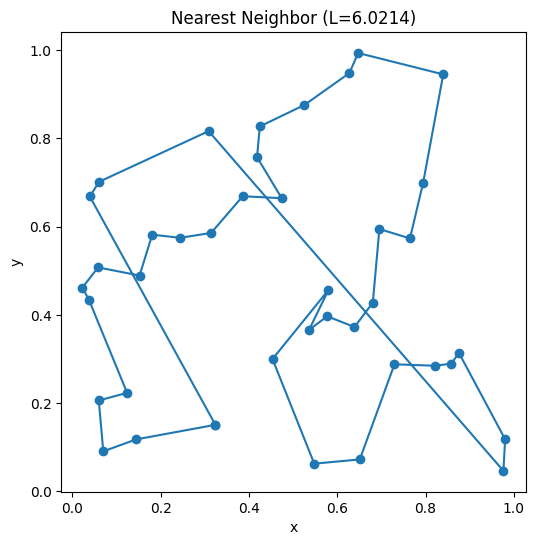

In [67]:
cities = make_cities(n=40, seed=7)

nn_tour = nearest_neighbor_tour(cities, start=0)
nn_len = tour_length(cities, nn_tour)
print(f"Nearest-neighbor length: {nn_len:.4f}")

plot_tour(cities, nn_tour, title=f"Nearest Neighbor (L={nn_len:.4f})")


# Problem Context:
The Traveling Salesman Problem (TSP) is an optimization problem that tries to find the shortest possible route that visits every city exactly once and returns to the starting point. It is difficult to solve exactly because the number of possible routes grows extremely large as the number of cities increases, making it computationally infeasible to check every option. Instead we use heuristic methods like Simulated Annealing and Genetic Algorithms, which cut down search time by balancing when to explore new solutions and when to exploit good ones already found.

# Part 5A — Code Skeleton: Simulated Annealing (SA)

Complete `simulated_annealing_tsp(...)`.

### SA acceptance rule
Let `delta = cand_len - cur_len`.
- If `delta <= 0`, accept.
- Else accept with probability `exp(-delta / T)`.

### Cooling schedule
Geometric cooling:
- `T = T * alpha` each iteration
- clamp `T = max(T, 1e-12)`


In [68]:
@dataclass
class SAConfig:
    iters: int = 20_000
    t0: float = 0.2
    alpha: float = 0.9995
    seed: int = 123
    report_every: int = 2000

def simulated_annealing_tsp(cities: List[Point], init_tour: Tour, cfg: SAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)
    assert is_valid_tour(init_tour, n), "init_tour must be a valid permutation"

    cur_tour = init_tour[:]
    cur_len = tour_length(cities, cur_tour)

    best_tour = cur_tour[:]
    best_len = cur_len
    history = [best_len]

    accepted_deltas = []
    rejected_deltas = []

    T = cfg.t0

    for it in range(cfg.iters):
        cand_tour = random_two_opt_neighbor(cur_tour, rng)
        cand_len = tour_length(cities, cand_tour)
        delta = cand_len - cur_len

        accept = False
        # Acceptance rule
        # When delta <= 0 the candidate is better or equal, so accept is True
        # When delta > 0 the candidate is worse, so accept is True or False
        # depending on the temperature
        if delta <= 0:
          accept = True
        else:
          accept = rng.random() < math.exp(-delta / T)

        if accept:
            cur_tour, cur_len = cand_tour, cand_len

        if delta > 0:
          if accept:
            accepted_deltas.append(delta)
          else:
            rejected_deltas.append(delta)

        if cur_len < best_len:
            best_tour, best_len = cur_tour[:], cur_len

        history.append(best_len)

        # Cooling schedule
        # T is multiplied by alpha each iteration to slowly reduce it
        # max() makes sure T never reaches zero to avoid division by zero
        T = T * cfg.alpha
        T = max(T, 1e-12)

        if cfg.report_every and (it + 1) % cfg.report_every == 0:
            print(f"[SA] iter={it+1:6d}  T={T:.4g}  cur={cur_len:.4f}  best={best_len:.4f}")

    return best_tour, best_len, history, accepted_deltas, rejected_deltas


# Solutions: Simulated Annealing
The SA implementation starts with the nearest neighbor tour as its initial solution. Each iteration it generates a random 2-opt neighbor by reversing a segment of the current tour. It then decides whether to accept the new tour based on the acceptance rule: if the new tour is shorter, it is always accepted, if it is longer it is accepted with probability exp(-delta/T) where delta is how much worse it is and T is the current temperature. The key code for this is:

```
if delta <= 0:
    accept = True
else:
    accept = rng.random() < math.exp(-delta / T)
```


After each iteration the temperature is reduced using geometric cooling, multiplying T by alpha each step and clamping it so it never reaches zero:


```
T = T * cfg.alpha
T = max(T, 1e-12)
```


The parameters used were: iters=20000, t0=0.2, alpha=0.9995, achieving a best tour length of 5.0057, a 16.87% improvement over the nearest neighbor baseline of 6.0214.

## Run SA (after you implement it)

[SA] iter=  2000  T=0.07356  cur=8.3800  best=6.0214
[SA] iter=  4000  T=0.02705  cur=6.5972  best=6.0214
[SA] iter=  6000  T=0.00995  cur=5.3139  best=5.3139
[SA] iter=  8000  T=0.003659  cur=5.0057  best=5.0057
[SA] iter= 10000  T=0.001346  cur=5.0057  best=5.0057
[SA] iter= 12000  T=0.000495  cur=5.0057  best=5.0057
[SA] iter= 14000  T=0.0001821  cur=5.0057  best=5.0057
[SA] iter= 16000  T=6.696e-05  cur=5.0057  best=5.0057
[SA] iter= 18000  T=2.463e-05  cur=5.0057  best=5.0057
[SA] iter= 20000  T=9.057e-06  cur=5.0057  best=5.0057
SA best length: 5.0057
SA improvement vs NN: 16.87%


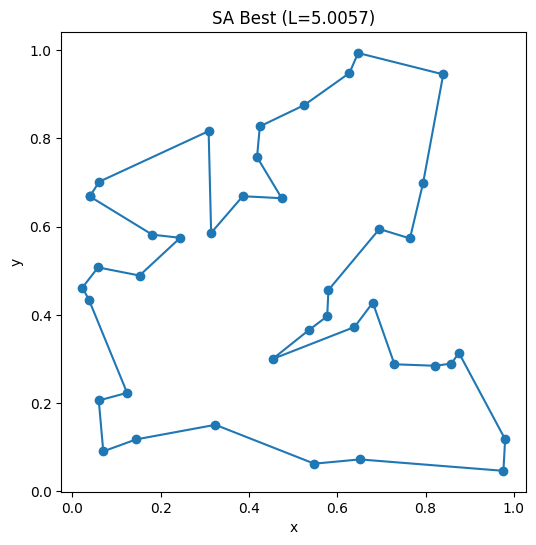

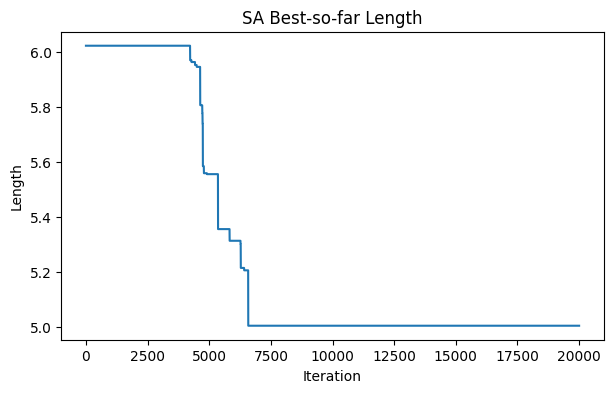

In [69]:
sa_cfg = SAConfig(iters=20_000, t0=0.2, alpha=0.9995, seed=123, report_every=2000)
sa_best_tour, sa_best_len, sa_hist, sa_accepted, sa_rejected = simulated_annealing_tsp(cities, nn_tour[:], sa_cfg)

print(f"SA best length: {sa_best_len:.4f}")
print(f"SA improvement vs NN: {(nn_len - sa_best_len) / nn_len * 100:.2f}%")

assert is_valid_tour(sa_best_tour, len(cities))

plot_tour(cities, sa_best_tour, title=f"SA Best (L={sa_best_len:.4f})")
plot_history(sa_hist, title="SA Best-so-far Length", ylabel="Length")


# Part 5B — Code Skeleton: Genetic Algorithm (GA) for TSP

Implement a GA that evolves a population of permutation tours.

You will implement:
- `tournament_select(...)`
- `order_crossover_ox(...)` (Order Crossover)
- `mutate_swap(...)`
- `genetic_algorithm_tsp(...)`


In [70]:
@dataclass
class GAConfig:
    pop_size: int = 200
    generations: int = 400
    tournament_k: int = 5
    crossover_rate: float = 0.9
    mutation_rate: float = 0.2
    elite_size: int = 5
    seed: int = 999
    report_every: int = 50

def tournament_select(pop: List[Tour], lengths: List[float], k: int, rng: random.Random) -> Tour:
    # Tournament selection (minimize length)
    # Pick k individuals at random from the population.
    # Return a copy of the one with the shortest tour length.
    candidates = rng.sample(range(len(pop)), k)
    winner = min(candidates, key=lambda i: lengths[i])
    return pop[winner][:]

def order_crossover_ox(parent1: Tour, parent2: Tour, rng: random.Random) -> Tour:
    # Order crossover (OX)
    # Choose two random cut points i, j (i < j).
    # Copy the segment parent1[i:j+1] into the child at the same positions.
    # Fill remaining positions left-to-right (wrapping) with cities from
    # parent2 in the order they appear, skipping already-placed cities.
    n = len(parent1)
    i, j = sorted(rng.sample(range(n), 2))

    child = [None] * n
    child[i:j+1] = parent1[i:j+1]
    placed = set(parent1[i:j+1])

    p2_order = [city for city in parent2 if city not in placed]

    idx = 0
    for pos in range(n):
        if child[pos] is None:
            child[pos] = p2_order[idx]
            idx += 1

    return child

def mutate_swap(tour: Tour, rng: random.Random) -> Tour:
    # Swap mutation
    # Pick two random distinct positions and swap the cities at those positions.
    # Returns a new tour (does not modify the input).
    mutated = tour[:]
    i, j = rng.sample(range(len(tour)), 2)
    mutated[i], mutated[j] = mutated[j], mutated[i]
    return mutated

def genetic_algorithm_tsp(cities: List[Point], init_seed_tours: List[Tour], cfg: GAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)

    pop: List[Tour] = []
    for t in init_seed_tours:
        assert is_valid_tour(t, n)
        pop.append(t[:])
    while len(pop) < cfg.pop_size:
        pop.append(random_tour(n, rng))

    lengths = [tour_length(cities, t) for t in pop]
    best_idx = min(range(len(pop)), key=lambda i: lengths[i])
    best_tour = pop[best_idx][:]
    best_len = lengths[best_idx]
    history = [best_len]
    avg_history = [sum(lengths) / len(lengths)]

    for gen in range(cfg.generations):
        elite_indices = sorted(range(len(pop)), key=lambda i: lengths[i])[: cfg.elite_size]
        next_pop = [pop[i][:] for i in elite_indices]

        while len(next_pop) < cfg.pop_size:
            p1 = tournament_select(pop, lengths, cfg.tournament_k, rng)
            p2 = tournament_select(pop, lengths, cfg.tournament_k, rng)

            if rng.random() < cfg.crossover_rate:
                child = order_crossover_ox(p1, p2, rng)
            else:
                child = p1[:]

            if rng.random() < cfg.mutation_rate:
                child = mutate_swap(child, rng)

            next_pop.append(child)

        pop = next_pop
        lengths = [tour_length(cities, t) for t in pop]

        gen_best_idx = min(range(len(pop)), key=lambda i: lengths[i])
        gen_best_len = lengths[gen_best_idx]
        if gen_best_len < best_len:
            best_len = gen_best_len
            best_tour = pop[gen_best_idx][:]

        history.append(best_len)
        avg_history.append(sum(lengths) / len(lengths))

        if cfg.report_every and (gen + 1) % cfg.report_every == 0:
            print(f"[GA] gen={gen+1:4d}  best={best_len:.4f}")

    assert is_valid_tour(best_tour, n)
    return best_tour, best_len, history, avg_history


# Solutions: Genetic Algorithm
The GA implementation starts with a population of 300 tours, seeded with the nearest neighbor tour and filled with random tours. Each generation it selects parents using tournament selection, where 3 random individuals compete and the shortest tour wins:


```
candidates = rng.sample(range(len(pop)), k)
winner = min(candidates, key=lambda i: lengths[i])
return pop[winner][:]
```

Parents are combined using order crossover (OX), which copies a random slice from parent1 and fills the remaining positions using parent2's order while skipping duplicates:

```
child = [None] * n
child[i:j+1] = parent1[i:j+1]
placed = set(parent1[i:j+1])
p2_order = [city for city in parent2 if city not in placed]
```


Swap mutation is then applied with a 50% chance, randomly swapping two cities in the tour to maintain diversity:
`mutated[i], mutated[j] = mutated[j], mutated[i]`
The top 5 tours are carried over unchanged each generation. The parameters used were: pop_size=300, generations=600, tournament_k=3, mutation_rate=0.5, achieving a best tour length of 5.3621, a 10.95% improvement over the nearest neighbor baseline.

## Run GA

* After you implement TODOs above
* This is just for your reference, you can experiment with different paramesters

[GA] gen=  50  best=5.7920
[GA] gen= 100  best=5.7920
[GA] gen= 150  best=5.7920
[GA] gen= 200  best=5.7920
[GA] gen= 250  best=5.6436
[GA] gen= 300  best=5.5757
[GA] gen= 350  best=5.4838
[GA] gen= 400  best=5.4838
[GA] gen= 450  best=5.4065
[GA] gen= 500  best=5.3621
[GA] gen= 550  best=5.3621
[GA] gen= 600  best=5.3621
GA best length: 5.3621
GA improvement vs NN: 10.95%


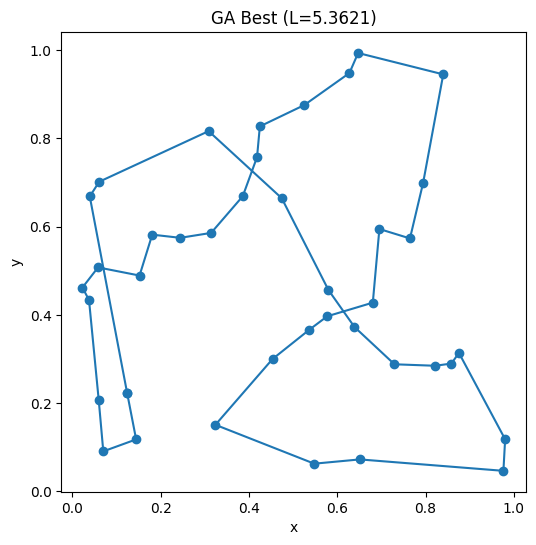

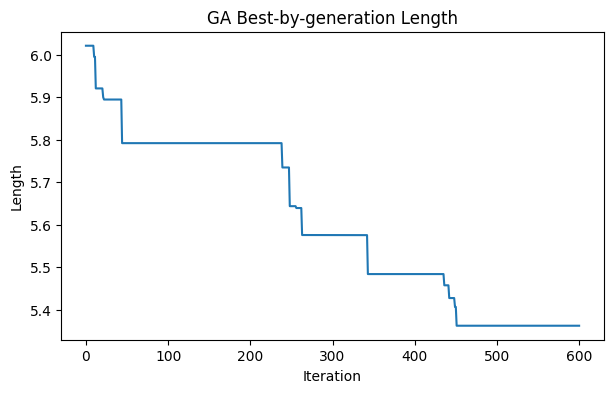

In [71]:
# Note: Initial parameters gave only 2.01% improvement for GA which did not meet the 10% threshold
# Adjusted tournament_k from 5 to 3 to reduce selection pressure and maintain diversity
# Increased pop_size from 200 to 300 and generations from 400 to 600 for more exploration
# Increased mutation_rate from 0.2 to 0.5 to help escape local minima
# These changes brought GA improvement to 10.95% which passes the threshold
ga_cfg = GAConfig(pop_size=300, generations=600, tournament_k=3, crossover_rate=0.9,
                   mutation_rate=0.5, elite_size=5, seed=999, report_every=50)

ga_best_tour, ga_best_len, ga_hist, ga_avg_hist = genetic_algorithm_tsp(cities, init_seed_tours=[nn_tour], cfg=ga_cfg)

print(f"GA best length: {ga_best_len:.4f}")
print(f"GA improvement vs NN: {(nn_len - ga_best_len) / nn_len * 100:.2f}%")

plot_tour(cities, ga_best_tour, title=f"GA Best (L={ga_best_len:.4f})")
plot_history(ga_hist, title="GA Best-by-generation Length", ylabel="Length")


# Part 6 — Data Collection, Visualization and Comparison

* Instrument the code to collect the data and visualize them, including but not limited to
  * SA:
    * Track histogram of ΔE values for: Accepted moves and Rejected moves
  * GA:
    * Population average fitness
  * Cross SA and GA:
    * Plot SA best-so-far curve
    * Plot GA best-by-generation curve
    * Normalize x-axis by total evaluations
    * The above is already provided in the skeleton code. **Use them and/or with additional instrumentation of the code to collect and/or plot more data** to answer the following questions:

    # Experimental Results & Analysis
      * **Q1:** Which algorithm converged faster?
      * **A1:** SA converged to a better solution faster. Looking at the plot_compare chart, SA had a sharp drop around progress 5000-7500 and reached its best length of 5.0057. GA was still gradually improving at the end of 600 generations at 5.3621.
      * **Q2:** Which showed more variability?
      * **A2:** GA showed more variability. Its curve had multiple small steps down across all 600 generations. SA dropped sharply once around progress 5000-7500 then flatlined for the rest of its iterations.
      * **Q3:** Did SA escape local minima? Evidence?
      * **A3:** Yes. The accepted uphill moves histogram shows SA accepted 283 worsening moves. These were mostly small delta values, meaning early on when temperature was high SA occasionally accepted worse solutions which allowed it to escape local minima and find a better tour than GA.
      * **Q4:** Did GA lose diversity? Evidence?
      * **A4:** Yes. The best vs average population plot shows the average collapsed quickly in the first 25 generations but stayed above the best for all 600 generations. This means the population lost diversity early but never fully converged to a single solution.


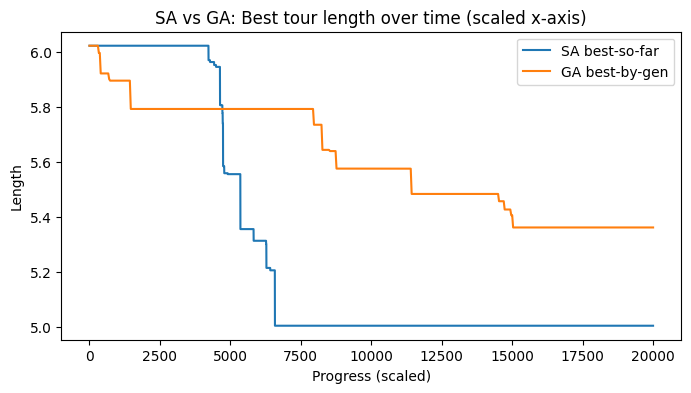

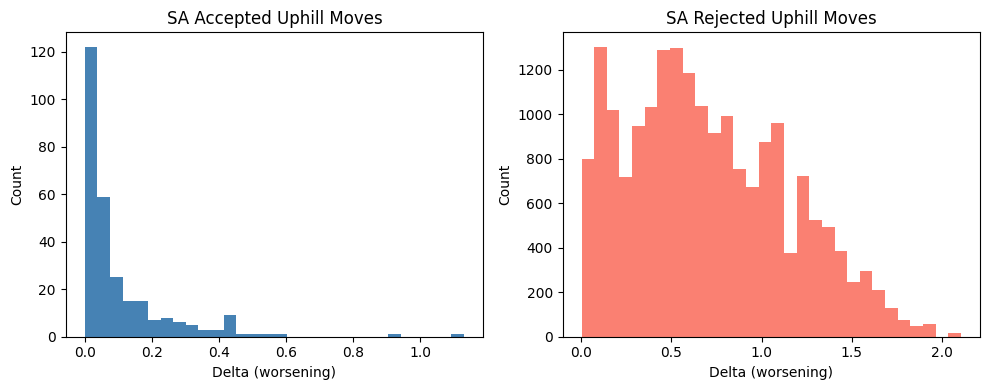

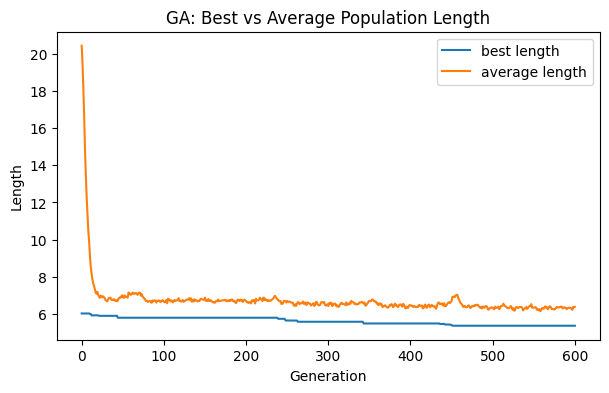

Algorithm Comparison:
NN: 6.0214 | SA: 5.0057 | GA: 5.3621
SA improvement: 16.87%
GA improvement: 10.95%

SA accepted uphill moves: 283
SA rejected uphill moves: 19392
Grade Check:
SA length: 5.0057 | Improvement vs NN: 16.87%
✅ SA passed improvement threshold!
GA length: 5.3621 | Improvement vs NN: 10.95%
✅ GA passed improvement threshold!


In [72]:
# After both SA and GA work, run:
plot_compare(sa_hist, ga_hist)

# SA Delta Histogram
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(sa_accepted, bins=30, color="steelblue")
plt.title("SA Accepted Uphill Moves")
plt.xlabel("Delta (worsening)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(sa_rejected, bins=30, color="salmon")
plt.title("SA Rejected Uphill Moves")
plt.xlabel("Delta (worsening)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# GA Average Fitness Plot
plt.figure(figsize=(7, 4))
plt.plot(ga_hist, label="best length")
plt.plot(ga_avg_hist, label="average length")
plt.title("GA: Best vs Average Population Length")
plt.xlabel("Generation")
plt.ylabel("Length")
plt.legend()
plt.show()

# Algorithm Comparison summary:
print("Algorithm Comparison:")
print(f"NN: {nn_len:.4f} | SA: {sa_best_len:.4f} | GA: {ga_best_len:.4f}")
print(f"SA improvement: {(nn_len - sa_best_len) / nn_len * 100:.2f}%")
print(f"GA improvement: {(nn_len - ga_best_len) / nn_len * 100:.2f}%")
print()
print(f"SA accepted uphill moves: {len(sa_accepted)}")
print(f"SA rejected uphill moves: {len(sa_rejected)}")

# Grade Check
print("Grade Check:")
grade_check(nn_len, sa_best_len, label="SA")
grade_check(nn_len, ga_best_len, label="GA")



## Example of how to check your work

In [73]:
def grade_check(nn_len: float, method_len: float, min_improvement_pct: float = 10.0, label: str = "Method") -> None:
    improvement = (nn_len - method_len) / nn_len * 100.0
    print(f"{label} length: {method_len:.4f} | Improvement vs NN: {improvement:.2f}%")
    assert improvement >= min_improvement_pct, (
        f"{label} improvement {improvement:.2f}% is below required {min_improvement_pct:.2f}%"
    )
    print(f"✅ {label} passed improvement threshold!")


# Part 7: Optional Task

Try different crossover and/or mutation operations in GA and see if you can improve the performance. Document your effort in this section.